# Exploring Argo in Med, Gulf of Mexico

In [1]:
# imports
import os
import glob
import numpy as np

from matplotlib import pyplot as plt
import datetime

import xarray
import pysolar

# Load up one

In [19]:
ifile = os.path.join(os.getenv('OS_DATA'), 'Argo', 'Med_Mexico',
                     'Ocean_Biogeochemistry_BGC-Argo_Global_Profiles_GulfofMexico.nc'
                    )

In [20]:
ds = xarray.open_dataset(ifile)

# Examine

In [8]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:                                          (N_STATIONS: 134,
                                                      N_SAMPLES: 559)
Dimensions without coordinates: N_STATIONS, N_SAMPLES
Data variables: (12/44)
    cruise_id                                        (N_STATIONS) |S7 938B ...
    station_id                                       (N_STATIONS) |S20 3kB ...
    station_type                                     (N_STATIONS) |S1 134B ...
    longitude                                        (N_STATIONS) float32 536B ...
    latitude                                         (N_STATIONS) float32 536B ...
    Direction                                        (N_STATIONS) |S13 2kB ...
    ...                                               ...
    Particle_backscattering_at_532_nm_original_      (N_STATIONS, N_SAMPLES) float32 300kB ...
    Particle_backscattering_at_532_nm_original__qc   (N_STATIONS, N_SAMPLES) float32 300kB ...
    Particle_backscattering_at_532_nm_adjusted_      (N_STATIONS, N_SAMPLES) float32 300kB ...
    Particle_backscattering_at_532_nm_adjusted__qc   (N_STATIONS, N_SAMPLES) float32 300kB ...
    Particle_beam_attenuation_at_660_nanometers      (N_STATIONS, N_SAMPLES) float32 300kB ...
    Particle_beam_attenuation_at_660_nanometers_qc   (N_STATIONS, N_SAMPLES) float32 300kB ...
Attributes:
    Conventions:         CF-1.7
    comment:             ODV NetCDF Export File V2.0
    Creator:             root@1f40930474af
    CreateTime:          2026-02-03T04:56:20
    Software:            Web Ocean Data View 5.8.3.2 - web_server: 46 - 64 bi...
    source:              /var/www/html/webodv/storage/app/default/Ocean/Bioge...
    SourceLastModified:  2026-02-02T13:09:56
    DataField:           Ocean
    DataType:            Profiles
    Description:         Biogeochemical Argo profile data for the global ocea...
    featureType:         profile

In [18]:
ds.longitude[0].values, ds.latitude[0].values

(array(-86.179016, dtype=float32), array(25.344, dtype=float32))

In [14]:
#ds.Particle_backscattering_at_700_nm_adjusted__qc
ds.Particle_backscattering_at_700_nm_adjusted_

<xarray.DataArray 'Particle_backscattering_at_700_nm_adjusted_' (
                                                                 N_STATIONS: 134,
                                                                 N_SAMPLES: 559)> Size: 300kB
[74906 values with dtype=float32]
Dimensions without coordinates: N_STATIONS, N_SAMPLES
Attributes:
    long_name:            Particle backscattering  at  700 nm (adjusted)
    units:                m~^-~^1
    comment:              BBP700_ADJUSTED
    ancillary_variables:  Particle_backscattering_at_700_nm_adjusted__qc Part...
    C_format:             %.3f
    FORTRAN_format:       F12.3

# Simple plot

In [10]:
prof = ds.isel(N_STATIONS=3)
prof

<xarray.Dataset> Size: 54kB
Dimensions:                                          (N_SAMPLES: 559)
Dimensions without coordinates: N_SAMPLES
Data variables: (12/44)
    cruise_id                                        |S7 7B ...
    station_id                                       |S20 20B ...
    station_type                                     |S1 1B ...
    longitude                                        float32 4B ...
    latitude                                         float32 4B ...
    Direction                                        |S13 13B ...
    ...                                               ...
    Particle_backscattering_at_532_nm_original_      (N_SAMPLES) float32 2kB ...
    Particle_backscattering_at_532_nm_original__qc   (N_SAMPLES) float32 2kB ...
    Particle_backscattering_at_532_nm_adjusted_      (N_SAMPLES) float32 2kB ...
    Particle_backscattering_at_532_nm_adjusted__qc   (N_SAMPLES) float32 2kB ...
    Particle_beam_attenuation_at_660_nanometers      (N_SAMPLES) float32 2kB ...
    Particle_beam_attenuation_at_660_nanometers_qc   (N_SAMPLES) float32 2kB ...
Attributes:
    Conventions:         CF-1.7
    comment:             ODV NetCDF Export File V2.0
    Creator:             root@1f40930474af
    CreateTime:          2026-02-03T04:56:20
    Software:            Web Ocean Data View 5.8.3.2 - web_server: 46 - 64 bi...
    source:              /var/www/html/webodv/storage/app/default/Ocean/Bioge...
    SourceLastModified:  2026-02-02T13:09:56
    DataField:           Ocean
    DataType:            Profiles
    Description:         Biogeochemical Argo profile data for the global ocea...
    featureType:         profile

In [11]:
prof.date_time

<xarray.DataArray 'date_time' ()> Size: 8B
[1 values with dtype=datetime64[ns]]
Attributes:
    long_name:       Decimal Gregorian Days of the station
    standard_name:   time
    comment:         Relative Gregorian Days with decimal part
    C_format:        %.5f
    FORTRAN_format:  F12.5

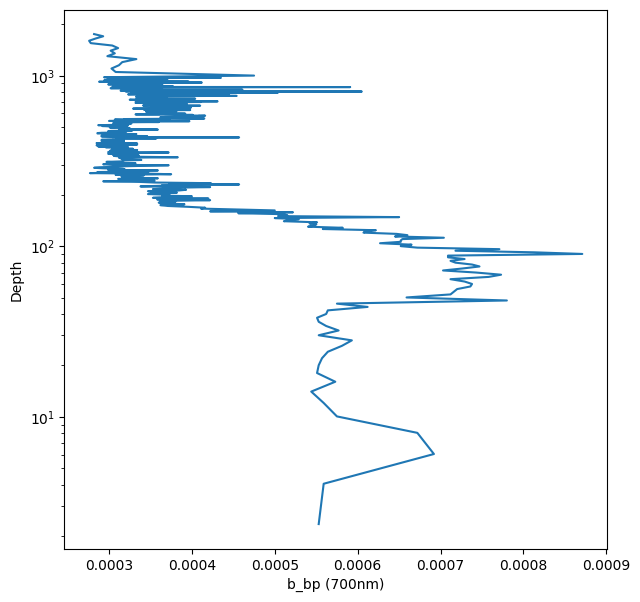

In [15]:
iprof = 3
ok = ds.Particle_backscattering_at_700_nm_adjusted__qc[iprof,:] <= 50
#
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(ds.Particle_backscattering_at_700_nm_adjusted_[iprof,ok],
        ds.Pressure_adjusted_.data[iprof,ok]) 
#
#ax.set_ylim(500.,0)
#
ax.set_xlabel('b_bp (700nm)')
ax.set_ylabel('Depth')
#
ax.set_yscale('log')
#
plt.show()